In [1]:
import xgboost
import shap
import numpy as np 
import pandas as pd

/home/z/mambaforge-pypy3/envs/zsl/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
shap.initjs()

In [3]:
df_yield = pd.read_csv('./data/raw.csv')
df_yield.shape

(26, 7)

In [4]:
from sklearn.preprocessing import StandardScaler

features = df_yield.drop(['yield'], axis=1)
y = df_yield['yield']
scaler = StandardScaler()

X = pd.DataFrame(scaler.fit_transform(features) ,columns=features.columns)

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


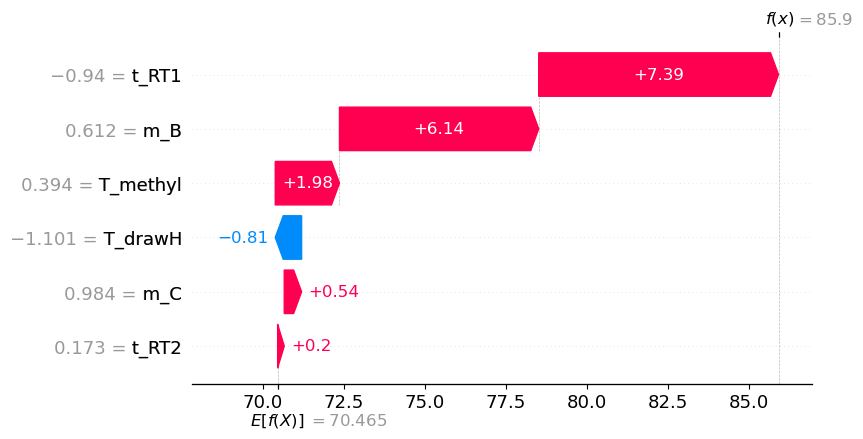

In [5]:
# train an XGBoost model
model = xgboost.XGBRegressor().fit(X, y)

# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(model)
shap_values = explainer(X)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[2])

In [6]:
# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[4])

In [10]:
# visualize all the training set predictions
shap.plots.force(shap_values)

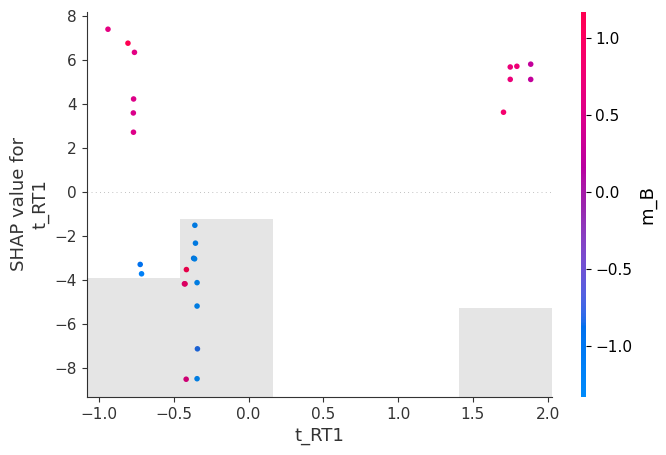

In [11]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:,"t_RT1"], color=shap_values)

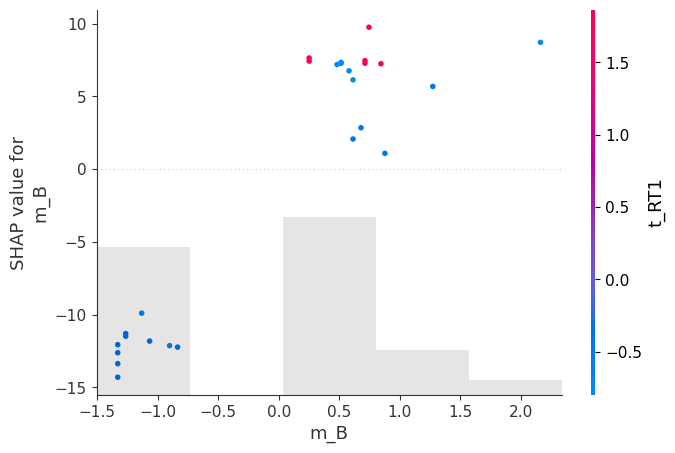

In [12]:
shap.plots.scatter(shap_values[:,"m_B"], color=shap_values)

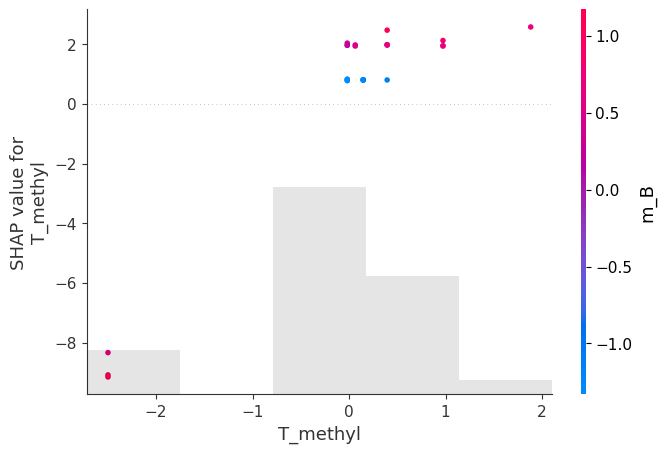

In [14]:
shap.plots.scatter(shap_values[:,"T_methyl"], color=shap_values)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


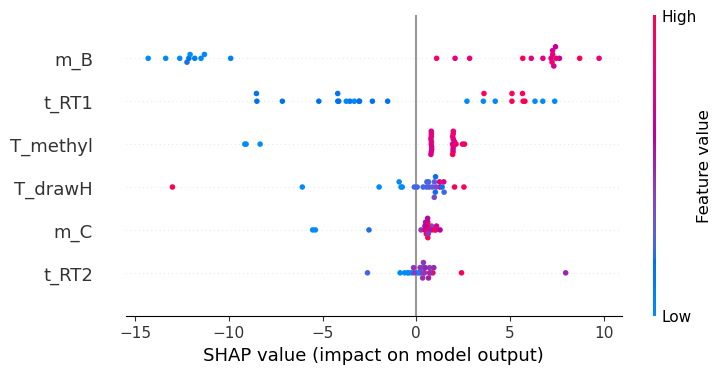

In [15]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

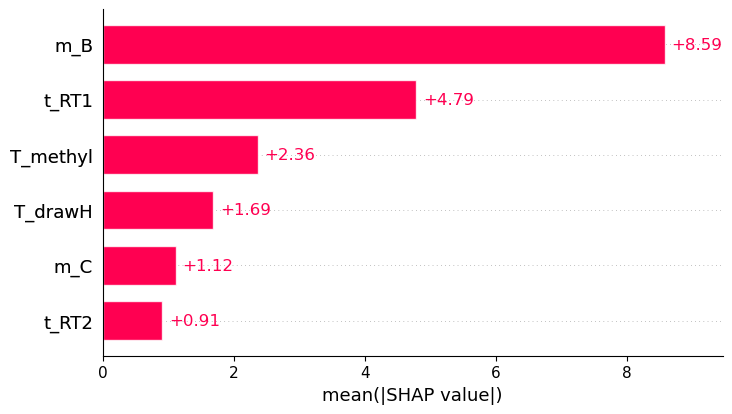

In [16]:
shap.plots.bar(shap_values)